In [1]:
import csv
import pandas as pd
from datasets import load_dataset
from database_interface import DatabaseHelper
from collections import Counter
# MODEL_OUTPUT_PATH = "/scratch/eecs595f25_class_root/eecs595f25_class/llada_data/synthetic_text_to_sql/output_sql.csv"
MODEL_OUTPUT_PATH = "/scratch/eecs595f25_class_root/eecs595f25_class/llada_data/"
OUTPUT_FILE_PATH = "/scratch/eecs595f25_class_root/eecs595f25_class/llada_data/synthetic_text_to_sql/valid_test.json"
output_files = [
    ("baseline.csv", "Baseline"),
    ("masking_and_gen_pred_res.csv", "Masking+Gen"),
    ("masking_only_res.csv", "Masking Only"),
    ("eval_results_ar.csv", "LLM")
]


In [5]:
dfs = []
for file_name, model_name in output_files:
    file = MODEL_OUTPUT_PATH + file_name
    df = pd.read_csv(file)
    df['model_type'] = model_name
    # Ensure time_taken is numeric
    df['time_taken'] = pd.to_numeric(df['time_taken'], errors='coerce')
    dfs.append(df[['id', 'time_taken', 'model_type']])

# Combine all into one DataFrame
timing_df = pd.concat(dfs, ignore_index=True)
print(timing_df.head())

   id  time_taken model_type
0   1   14.431595   Baseline
1   3   12.477610   Baseline
2   4   11.397552   Baseline
3   5   13.394053   Baseline
4   7   13.611531   Baseline


In [6]:
timing = pd.to_numeric(timing_df['time_taken'], errors='coerce').dropna()

print("Timing statistics by Model (in seconds):")
print("-" * 60)

# Iterate through each model to print the specific stats you wanted
for model, data in timing_df.groupby('model_type'):
    times = data['time_taken']
    print(f"Model: {model}")
    print(f"  Mean: {times.mean():.3f}")
    print(f"  Median: {times.median():.3f}")
    print(f"  Min: {times.min():.3f}")
    print(f"  Max: {times.max():.3f}")
    print(f"  Std: {times.std():.3f}")
    print(f"  90th percentile: {times.quantile(0.9):.3f}")
    print(f"  95th percentile: {times.quantile(0.95):.3f}")
    print(f"  99th percentile: {times.quantile(0.99):.3f}")
    print(f"  Count: {times.count()}")
    print("-" * 30)

Timing statistics by Model (in seconds):
------------------------------------------------------------
Model: Baseline
  Mean: 12.427
  Median: 12.755
  Min: 7.744
  Max: 21.568
  Std: 1.946
  90th percentile: 14.587
  95th percentile: 15.858
  99th percentile: 17.688
  Count: 1151
------------------------------
Model: LLM
  Mean: 1.282
  Median: 1.079
  Min: 0.411
  Max: 14.864
  Std: 0.738
  90th percentile: 2.015
  95th percentile: 2.445
  99th percentile: 3.919
  Count: 3100
------------------------------
Model: Masking Only
  Mean: 19.716
  Median: 18.995
  Min: 16.886
  Max: 51.668
  Std: 2.385
  90th percentile: 22.642
  95th percentile: 23.245
  99th percentile: 27.777
  Count: 701
------------------------------
Model: Masking+Gen
  Mean: 12.773
  Median: 13.075
  Min: 7.809
  Max: 19.522
  Std: 2.022
  90th percentile: 15.054
  95th percentile: 16.387
  99th percentile: 18.326
  Count: 1101
------------------------------


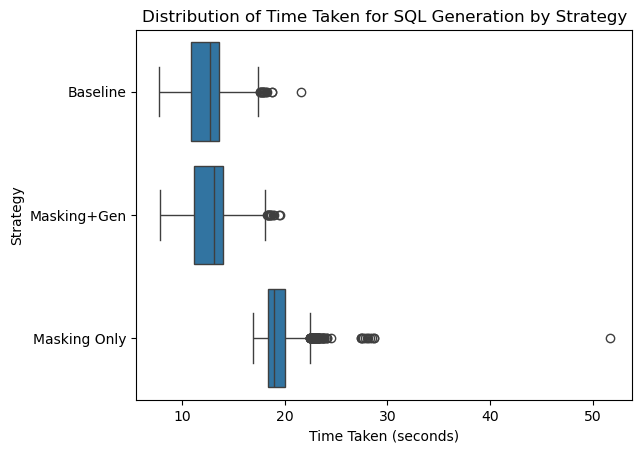

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=timing_df, x='time_taken', y='model_type')

plt.title("Distribution of Time Taken for SQL Generation by Strategy")
plt.xlabel("Time Taken (seconds)")
plt.ylabel("Strategy")
plt.show()